In [1]:
import torch
from torch import nn
from torch.utils import data
import torchvision
from torchvision import transforms

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
trans=transforms.ToTensor()
mnist_train=torchvision.datasets.FashionMNIST(root="../data",train=True,transform=trans,download=False)
mnist_test=torchvision.datasets.FashionMNIST(root="../data",train=False,transform=trans,download=False)

train_iter=data.DataLoader(mnist_train,batch_size=256,shuffle=True)
test_iter=data.DataLoader(mnist_test,batch_size=256,shuffle=False)

In [4]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.linear1=nn.Linear(28*28,256)
    self.relu=nn.ReLU()
    self.linear2=nn.Linear(256,10)
    nn.init.normal_(self.linear1.weight,std=0.01)
    nn.init.normal_(self.linear2.weight,std=0.01)
    
  def forward(self,x):
    x=self.flatten(x)
    x=self.linear1(x)
    x=self.relu(x)
    x=self.linear2(x)
    return x

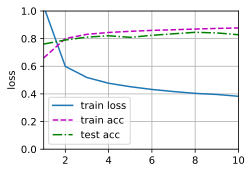

In [7]:
net=MLP()
net.to(device)
loss=nn.CrossEntropyLoss()
trainer=torch.optim.SGD(net.parameters(),lr=0.1)
num_epochs=10
import sys
sys.path.append('..')
from tools.ANIMATOR import Animator
animator=Animator(xlabel='epoch',ylabel='loss',xlim=[1,num_epochs],ylim=[0,1.0],legend=['train loss','train acc','test acc'])
from tools.ACCURACY import evalute_acc
for epoch in range(num_epochs):
    train_loss,train_acc,total_num=0.0,0.0,0
    for X,y in train_iter:
        total_num+=X.shape[0]
        X,y=X.to(device),y.to(device)
        trainer.zero_grad()
        l=loss(net(X),y)
        l.backward()
        trainer.step()
        train_loss+=l.sum().item()*X.shape[0]
        train_acc+=(net(X).argmax(axis=1)==y).sum()
    test_acc=evalute_acc(net,test_iter,device)
    animator.add(epoch+1,[float(train_loss/total_num),float(train_acc/total_num),float(test_acc)])